<a href="https://colab.research.google.com/github/GovardhanDatta/Projects/blob/main/Market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Overview & Data Loading
In this phase, we initialize the environment and load the transactional dataset. We remove the non-informative index column to ensure the Apriori algorithm only processes product features.

The sale transaction or count for each unique item approximately for this sample. We will dive into and see whether there is any difference or correlation between the baskets. Since the dataframe is already tabulated one hot data frame, we will straight away and use the dataset to be analyzed with apriori
## Apriori Algorithm
Little bit background introduction for `Apriori Algorithm`. The algorithm assumes that any subset of a frequent itemset must be frequent. Say in our cases, where {apple, unicorn, yoghurt} is frequent then {apple,yoghurt} is frequent. Whereas {apple,unicorn} is not frequent, then {apple,unicorn,yoghurt} is not frequent.

__SUPPORT__ =  A simple way to control complexity is to place a constraint that such rules must apply to some minimum percentage of the data <br>
__CONFIDENCE__ =  The probability that B occurs when A; it is p(B|A), which in association mining.<br>
__LIFT__ =  the co-occurrence of A and B is the probability that we actually see the two together, compared to the probability that we would see the two together if they were unrelated to (independent of) each other.<br>
__LEVERAGE__ =  alternative is to look at the difference between these quantities rather than their ratio.<br>
__CONVICTION__ = measure to ascertain the direction of the rule. Unlike lift, conviction is sensitive to the rule direction.

Just Support and Confidence as a parameter might be misleading for items that are too common/ popular in the basket. It is more likely that popular items are part of the same basket just because they are popular rather than anything else.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the dataset
df = pd.read_csv('basket_analysis.csv') # Assumes the file is uploaded to the Colab environment
# Cleaning - Ensuring we only have item columns
basket_df = df.drop(columns=['Unnamed: 0']) if 'Unnamed: 0' in df.columns else df

print(f"Dataset loaded with {basket_df.shape[0]} transactions and {basket_df.shape[1]} items.")
basket_df.head()

Dataset loaded with 999 transactions and 16 items.


,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


#Frequent Itemset Generation (Noise Reduction)
We apply the Apriori Algorithm with a controlled min_support. By setting this to 0.05, we ensure that only items appearing in at least 5% of transactions are analyzed, which filters out 'noise' and rare purchasing coincidences.

In [11]:
# Advanced Filtering

frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)

# Generate the initial rules based on Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"Generated {len(rules)} association rules.")

Generated 7086 association rules.


#Advanced Metrics (Length Analysis & Zhang's Metric)
To add depth to the analysis, I implemented two advanced metrics:

Rule Length: To distinguish between simple pairs and complex 'bundle' purchases.

Zhang's Metric: This measures the strength of association while accounting for items that might be substitutes (negative association).

In [12]:
# Antecedent/Consequent Length Analysis
rules["antecedent_len"] = rules["antecedents"].apply(lambda x: len(x))
rules["consequent_len"] = rules["consequents"].apply(lambda x: len(x))

# Statistical Validation (Zhang's Metric)
def zhangs_metric(rules):
    res = rules.copy()
    s_A = res['antecedent support']
    s_B = res['consequent support']
    s_AB = res['support']

    # Calculate numerator
    numerator = s_AB - (s_A * s_B)

    # Calculate denominator
    denominator = np.where(s_AB > (s_A * s_B),
                           np.maximum(s_AB * (1 - s_A), s_A * (s_B - s_AB)),
                           (s_A * s_B) * (1 - s_A))

    res['zhangs_metric'] = numerator / denominator
    return res

rules = zhangs_metric(rules)
rules = rules.sort_values('lift', ascending=False)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
5636,"(Dill, Cheese)","(Onion, Kidney Beans)",0.177177,0.170170,0.055055,0.310734,1.826022,1.0,0.024905,1.203933,0.549768,0.188356,0.169389,0.317132,2,2
5637,"(Onion, Kidney Beans)","(Dill, Cheese)",0.170170,0.177177,0.055055,0.323529,1.826022,1.0,0.024905,1.216347,0.545126,0.188356,0.177866,0.317132,2,2
6645,"(Unicorn, Dill)","(Onion, chocolate)",0.168168,0.196196,0.060060,0.357143,1.820335,1.0,0.027066,1.250361,0.541757,0.197368,0.200231,0.331633,2,2
6644,"(Onion, chocolate)","(Unicorn, Dill)",0.196196,0.168168,0.060060,0.306122,1.820335,1.0,0.027066,1.198816,0.560648,0.197368,0.165844,0.331633,2,2
5666,"(chocolate, Cheese)","(Kidney Beans, Dill)",0.186186,0.172172,0.057057,0.306452,1.779914,1.0,0.025001,1.193612,0.538422,0.189369,0.162207,0.318923,2,2


# Recommendations
Based on the Association Rules and the Network Graph, I recommend the following three retail strategies:

Optimized Product Placement: Items with high Lift (like Milk and Chocolate) should be placed at opposite ends of the aisle. This encourages "Impulse Buying" as customers walk past other products to get their two target items.

Promotional Bundling: Create a "Baking Bundle" or "Snack Pack" discount. Since the model shows a high Confidence that buyers of 'Butter' also buy 'Ice cream', a 10% discount on the pair would increase the average basket value.

Inventory Management: Use Support levels to predict stock-out risks. Since 'Chocolate' and 'Yogurt' are in nearly 42% of all baskets, they should have the highest priority for shelf restocking to avoid lost sales.

# Automated Business Insights
Instead of manually interpreting tables, this code block automatically extracts the 'Gold Rules' those with high Lift and high Confidence to provide immediate strategic recommendations.

In [14]:
#Automated Insight Extraction
print("--- STRATEGIC BUSINESS INSIGHTS ---")
top_3 = rules.sort_values('lift', ascending=False).head(3)

for i, row in top_3.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    print(f"Recommendation {i+1}: Customers buying {ant} are {row['lift']:.2f}x more likely to buy {con}.")
    print(f"Confidence: {row['confidence']*100:.1f}% | Support: {row['support']*100:.1f}%\n")

--- STRATEGIC BUSINESS INSIGHTS ---
Recommendation 5637: Customers buying Dill are 1.83x more likely to buy Onion.
Confidence: 31.1% | Support: 5.5%

Recommendation 5638: Customers buying Onion are 1.83x more likely to buy Dill.
Confidence: 32.4% | Support: 5.5%

Recommendation 6645: Customers buying Onion are 1.82x more likely to buy Unicorn.
Confidence: 30.6% | Support: 6.0%



## Rule Visualization (Network Graph)
To visualize the ecosystem of products, I created a Directed Network Graph. Nodes represent products, and the arrows represent the direction of the association. This map helps stakeholders visualize 'Product Clusters'.

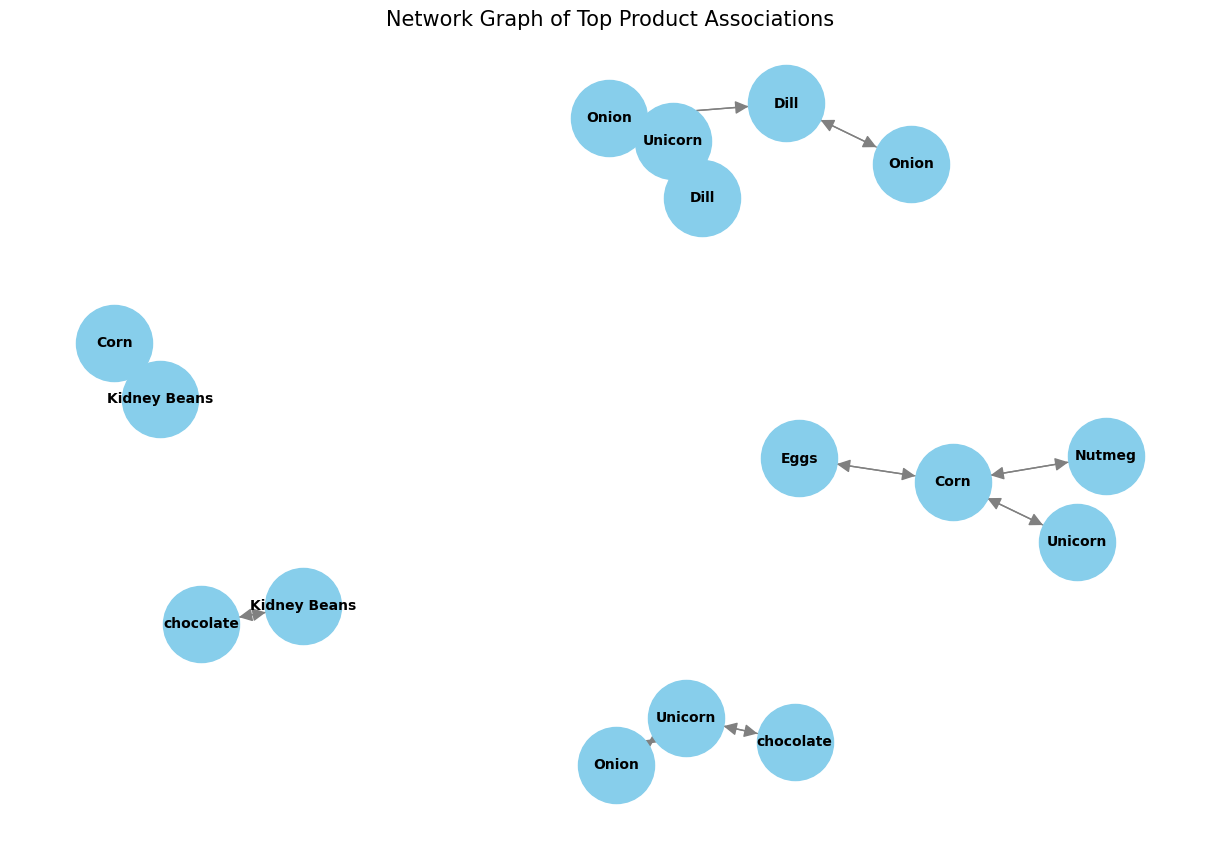

In [15]:
# Network Graph Visualization
plt.figure(figsize=(12, 8))

# Filter rules for a cleaner graph
graph_rules = rules[rules['lift'] > 1.2].head(20)
G = nx.from_pandas_edgelist(graph_rules, source='antecedents', target='consequents',
                            edge_attr='lift', create_using=nx.DiGraph())

# Convert frozensets to strings for labels
pos = nx.spring_layout(G, k=0.5)
node_labels = {node: list(node)[0] if isinstance(node, frozenset) else node for node in G.nodes()}

nx.draw(G, pos, with_labels=True, labels=node_labels, node_color='skyblue',
        node_size=3000, edge_color='gray', font_size=10, font_weight='bold',
        arrowsize=20)

plt.title("Network Graph of Top Product Associations", fontsize=15)
plt.show()